In [3]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date, datetime, timedelta
from matplotlib.dates import MO, TU, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date, timezone
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
import numpy as np

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo


# Make the data on each chart today's date
def format_date_with_suffix(date_obj):
    day = date_obj.day
    # Determine the ordinal suffix
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return date_obj.strftime(f"%B {day}{suffix}, %Y")

today = datetime.today()
date = format_date_with_suffix(today)

# Color utils
color_palette = {'Hyperliquid':'#09b882','Bold Blue':'#1f1f60', 'Sky Blue':'#6f85ee', 'Solana Purple':'#9945FF','Engage Orange':'#eda024', 'Dark Slate':'#262935', 'Mauve':'#7c1158', 'Yellow':'#ebdc78', 'Green':'#00b7c7', 'Red':'#b30000','Mid Grey':'#54504c','Other Grey':'#a4a2a8', 'Pure Grey': '#808080','Lighter Grey': '#A9A9A9','Lightest Grey': '#D3D3D3','blue 1':'#03045e', 'blue 2':'#0077b6', 'blue 3':'#00b4d8', 'blue 4':'#90e0ef', 'blue 5':'#caf0f8'}
platform_colors = {
        'Felix': color_palette['Sky Blue'],  
        'Hyperliquid': color_palette['Hyperliquid'],  
        'Jupiter': color_palette['Bold Blue'],      
        'dYdX v4': color_palette['Sky Blue'],      
        'ApeX': color_palette['Engage Orange'],         
        'Holdstation': color_palette['Yellow'],  
        'Vertex Protocol': color_palette['Green'], 
        'GMX': color_palette['Red'],          
        'dYdX v3': color_palette['Dark Slate'],      
        'Drift Protocol': color_palette['Mauve'],
        'RabbitX': color_palette['Mid Grey'],           
        'dYdX': color_palette['Dark Slate'],
        'Gains Network': color_palette['Mauve'],
        'KTX Finance': color_palette['Yellow'],
        'RabbitX': color_palette['Pure Grey'],
        'Aevo': color_palette['Lighter Grey'],
        'Other': color_palette['Other Grey'],
        'Hyperliquid Perps': color_palette['Hyperliquid'],
        'Jupiter Perpetual Exchange': color_palette['Bold Blue'],
        'Vertex Perps': color_palette['Green'],
        'Apex Omni': color_palette['Engage Orange'],
        'MYX Finance': color_palette['Yellow'],
        'edgeX': color_palette['Red'],
        'Ostium': color_palette['Mauve'],
        'RabitX': color_palette['Yellow'],
        'Aark Digital': color_palette['Dark Slate'],
        'dYdX (V3+V4)': color_palette['Sky Blue']
    }

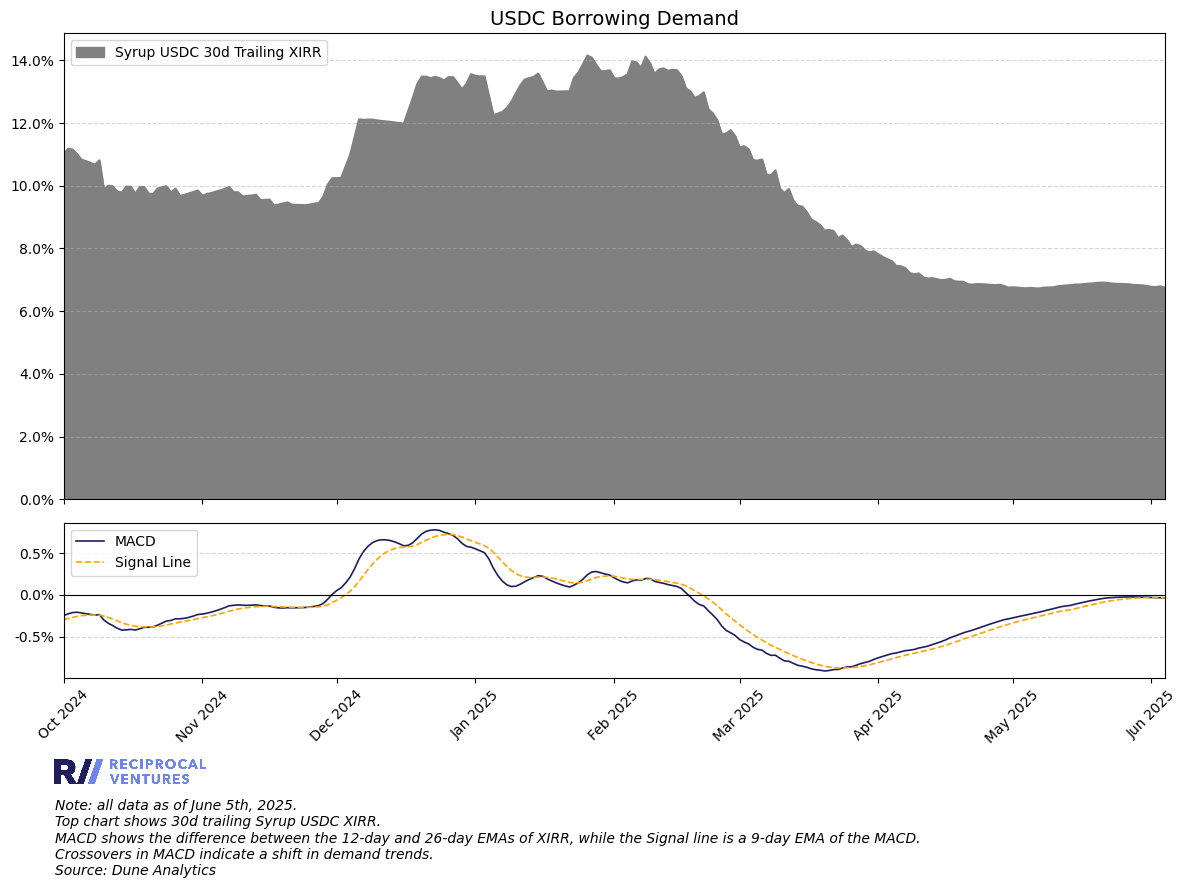

In [4]:
# Load the JSON file
with open("raw-data/dune-raw-data/dune_maple-xirr.json", "r") as f:
    raw_data = json.load(f)

# Extract relevant rows only for "Syrup USDC"
entries = raw_data["result"]["rows"]
syrup_usdc_rows = [e for e in entries if e["pool_name"] == "Syrup USDC"]

# Convert to DataFrame
df = pd.DataFrame(syrup_usdc_rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df['percent_xirr'] = df['trailing_xirr'] * 100

# Compute EMA and MACD
def compute_ema(values, period):
    ema = [None] * len(values)
    multiplier = 2 / (period + 1)

    # Find first index with enough non-None values
    valid_start = next((i for i in range(len(values)) if values[i] is not None), None)
    if valid_start is None or valid_start + period > len(values):
        return ema  # not enough data

    # Initialize EMA at first valid point
    ema[valid_start + period] = sum(values[valid_start:valid_start + period]) / period

    for i in range(valid_start + period + 1, len(values)):
        if values[i] is not None and ema[i - 1] is not None:
            ema[i] = (values[i] - ema[i - 1]) * multiplier + ema[i - 1]

    return ema

# Extract values
dates = df["date"].tolist()
percent_xirrs = df['percent_xirr'].tolist()

# Calculate EMAs and MACD
ema_12 = compute_ema(percent_xirrs, 12)
ema_26 = compute_ema(percent_xirrs, 26)
macd = [e12 - e26 if e12 is not None and e26 is not None else None for e12, e26 in zip(ema_12, ema_26)]

# Clean None values from MACD before computing signal line
macd_cleaned = [v if v is not None else 0 for v in macd]
signal = compute_ema(macd_cleaned, 9)

# Add back to the dataframe
df['ema_12'] = ema_12
df['ema_26'] = ema_26
df['macd'] = macd_cleaned
df['signal'] = signal

# Filter to cutoff date
df = df[df["date"] >= '2024-10-01'].reset_index(drop=True)

# Create figure with two subplots (main + MACD)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Area chart for XIRR
ax1.fill_between(df['date'], df['percent_xirr'], color=color_palette['Pure Grey'], alpha=1, label="Syrup USDC 30d Trailing XIRR")
ax1.plot(df['date'], df['percent_xirr'], color=color_palette['Pure Grey'], linewidth=1.5)
ax1.set_title("USDC Borrowing Demand", fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")
ax1.set_ylim(bottom=0)

# MACD Indicator
# MACD shows the difference between the 12-day and 26-day EMAs of XIRR, while the Signal line is a 9-day EMA of the MACD. Crossovers may indicate shifts in APY momentum.
ax2.plot(df['date'], df['macd'], label="MACD", color="#1f1f60", linewidth=1.2)
ax2.plot(df['date'], df['signal'], label="Signal Line", color="orange", linestyle="--", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

# X-axis formatting
ax1.margins(x=0)
ax2.margins(x=0)
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Format y-axis on main chart as %
def percent_formatter(x, pos):
    return f"{x:.1f}%"
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(percent_formatter))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(percent_formatter))

# Add Reciprocal logo and source note
add_logo(ax2, position=(0.06, -0.6))
plt.figtext(0.05, -0.1, f"Note: all data as of {date}.\nTop chart shows 30d trailing Syrup USDC XIRR.\nMACD shows the difference between the 12-day and 26-day EMAs of XIRR, while the Signal line is a 9-day EMA of the MACD.\nCrossovers in MACD indicate a shift in demand trends.\nSource: Dune Analytics", ha='left', fontsize=10, style='italic')

# Save and show
imgtitle = "usdc-30d-trailing-xirr-and-macd"
plt.tight_layout()
save_path = os.path.join("plots", f"{imgtitle}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# function to pull network FDV - native asset FDV - stablecoin suppy over a period of time

def non_native_network_fdv(start_date, end_date, network, native_asset):
    